In [ ]:
# ============================================================
# LINEAR ML MODELS — Google Colab Ready
# ============================================================
# Run each section independently or all at once.
# Install: pip install numpy matplotlib scikit-learn
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)


2. RIDGE REGRESSION (L2)
Alpha      Coef[0]      Coef[1]      MSE        R²
--------------------------------------------------------
0.01       1.9442       -1.4555      4.8161     0.5594
1          1.5935       -1.4501      4.8278     0.5583
10         1.3040       -1.3852      4.8544     0.5559
100        0.9802       -0.9563      5.3910     0.5068


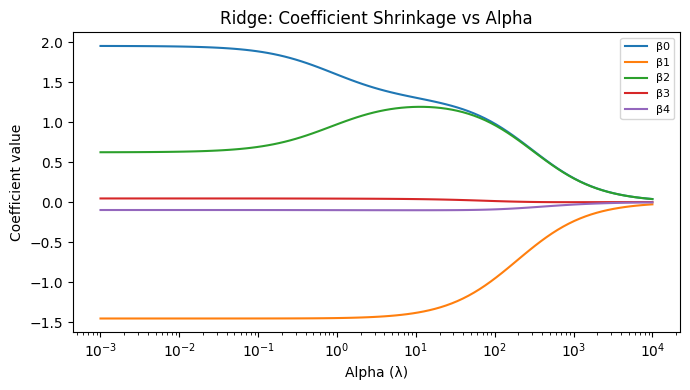

In [3]:
# ============================================================
# 2. RIDGE REGRESSION (L2 Regularization)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

print("\n" + "=" * 50)
print("2. RIDGE REGRESSION (L2)")
print("=" * 50)

# Generate multi-feature data with correlated features
X_ridge = np.random.randn(200, 5)
X_ridge[:, 2] = X_ridge[:, 0] + np.random.randn(200) * 0.1   # correlated feature
y_ridge = 2*X_ridge[:,0] - 1.5*X_ridge[:,1] + 0.5*X_ridge[:,2] + np.random.randn(200)*2

X_train, X_test, y_train, y_test = train_test_split(X_ridge, y_ridge, test_size=0.2, random_state=42)

alphas = [0.01, 1, 10, 100]
print(f"{'Alpha':<10} {'Coef[0]':<12} {'Coef[1]':<12} {'MSE':<10} {'R²'}")
print("-" * 56)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    print(f"{alpha:<10} {ridge.coef_[0]:<12.4f} {ridge.coef_[1]:<12.4f} "
          f"{mean_squared_error(y_test, y_pred):<10.4f} {r2_score(y_test, y_pred):.4f}")

# Plot: coefficient shrinkage vs alpha
all_coefs = []
alpha_range = np.logspace(-3, 4, 100)
for alpha in alpha_range:
    r = Ridge(alpha=alpha)
    r.fit(X_train, y_train)
    all_coefs.append(r.coef_)

all_coefs = np.array(all_coefs)
plt.figure(figsize=(7, 4))
for i in range(X_ridge.shape[1]):
    plt.plot(alpha_range, all_coefs[:, i], label=f'β{i}')
plt.xscale('log')
plt.xlabel("Alpha (λ)"); plt.ylabel("Coefficient value")
plt.title("Ridge: Coefficient Shrinkage vs Alpha")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


3. LASSO REGRESSION (L1)
Alpha      Coef[0]      Coef[1]      Zeros    R²
----------------------------------------------------
0.01       1.9687       -1.4472      0        0.5590
0.1        2.0011       -1.3735      1        0.5537
1          1.5418       -0.6137      3        0.4254
5          0.0000       -0.0000      5        -0.0717


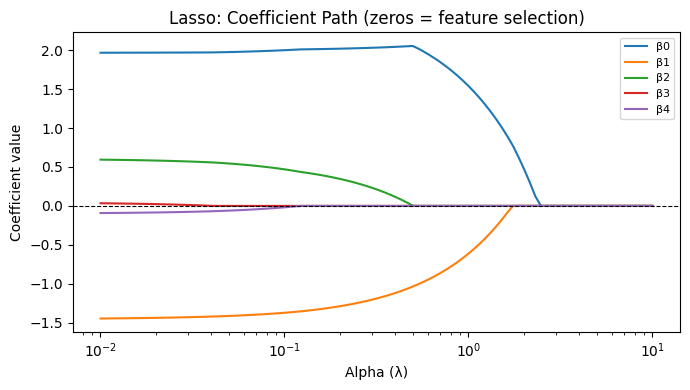

In [4]:
# ============================================================
# 3. LASSO REGRESSION (L1 Regularization)
# ============================================================

print("\n" + "=" * 50)
print("3. LASSO REGRESSION (L1)")
print("=" * 50)

# Same data as Ridge
X_train, X_test, y_train, y_test = train_test_split(X_ridge, y_ridge, test_size=0.2, random_state=42)

alphas_lasso = [0.01, 0.1, 1, 5]
print(f"{'Alpha':<10} {'Coef[0]':<12} {'Coef[1]':<12} {'Zeros':<8} {'R²'}")
print("-" * 52)

for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    n_zeros = np.sum(lasso.coef_ == 0)
    print(f"{alpha:<10} {lasso.coef_[0]:<12.4f} {lasso.coef_[1]:<12.4f} "
          f"{n_zeros:<8} {r2_score(y_test, y_pred):.4f}")

# Plot: Lasso path
all_coefs_lasso = []
alpha_range_lasso = np.logspace(-2, 1, 100)
for alpha in alpha_range_lasso:
    l = Lasso(alpha=alpha, max_iter=10000)
    l.fit(X_train, y_train)
    all_coefs_lasso.append(l.coef_)

all_coefs_lasso = np.array(all_coefs_lasso)
plt.figure(figsize=(7, 4))
for i in range(X_ridge.shape[1]):
    plt.plot(alpha_range_lasso, all_coefs_lasso[:, i], label=f'β{i}')
plt.xscale('log')
plt.xlabel("Alpha (λ)"); plt.ylabel("Coefficient value")
plt.title("Lasso: Coefficient Path (zeros = feature selection)")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()